In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from endgame.ncaabb import NcaabbGender

from cassandra.brier import brier_score_df
from cassandra.columns import GameDfColumns
from cassandra.predictor import load_predictor
from cassandra.prob_to_margin import IsotonicProbToMarginFitter
from cassandra.save_predictions import build_predictions_df

plt.style.use("ggplot")

In [2]:
gender = NcaabbGender.mens
models = Path.cwd().parent / "models" / gender.name

In [3]:
async def _get_df(predictor_config_path: Path) -> pd.DataFrame:
    # TODO: should this be a function shared with model_eval.py?
    predictor = load_predictor(predictor_config_path)
    fitter = IsotonicProbToMarginFitter()

    df = await build_predictions_df(predictor, gender, post_callbacks=False)

    brier_score = brier_score_df(df)

    # Fit on the margin every game finished at, so every game trains the
    # fitter, not just the ones a book put a line on.
    df = df.assign(team1_mov=lambda x: x.home_score - x.away_score)
    margin_predictor = fitter.fit_df(df)
    df = df.assign(
        predicted_margin=lambda x: margin_predictor.predict_margins(
            x[GameDfColumns.TEAM1_WIN_PROB].to_numpy()
        )
    )

    # Grading a bet still needs a line, so that part is the lined games only.
    with_spread = df[df[GameDfColumns.SPREAD].notna()]
    df = with_spread.assign(
        bet_team1=lambda df: df.predicted_margin > -df.spread,
        team1_covered=lambda df: df.spread + df.team1_mov > 0,
        correct_bet=lambda df: df.bet_team1 == df.team1_covered,
    )

    return pd.concat(
        [
            df.assign(
                team=lambda df: df.home_team,
                mov=lambda df: df.team1_mov,
            )[["team", "mov", "correct_bet"]],
            df.assign(
                team=lambda df: df.away_team,
                mov=-df.team1_mov,
            )[["team", "mov", "correct_bet"]],
        ]
    )

In [4]:
df = await _get_df(models / "Elo_result.json")

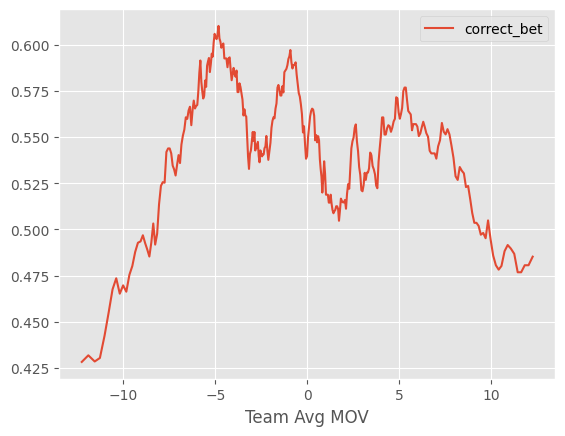

In [5]:
before_teams = (
    df.groupby("team").agg({"mov": "mean", "correct_bet": "mean"}).reset_index()
)
(
    before_teams.sort_values("mov")[["mov", "correct_bet"]]
    .rolling(window=50, center=True)
    .mean()
    .plot("mov", "correct_bet")
    .set_xlabel("Team Avg MOV")
);

So, teams with high (or low) avg MOVs do worse.
The ideas is we're not rewarding/punishing high MOV games enough.

In [6]:
after_df = await _get_df(models / "Elo538_result.json")

In [7]:
after_teams = (
    after_df.groupby("team").agg({"mov": "mean", "correct_bet": "mean"}).reset_index()
)

In [8]:
combined = before_teams.merge(after_teams, on="team", suffixes=("", "_after")).assign(
    improvement=lambda x: x.correct_bet_after - x.correct_bet
)

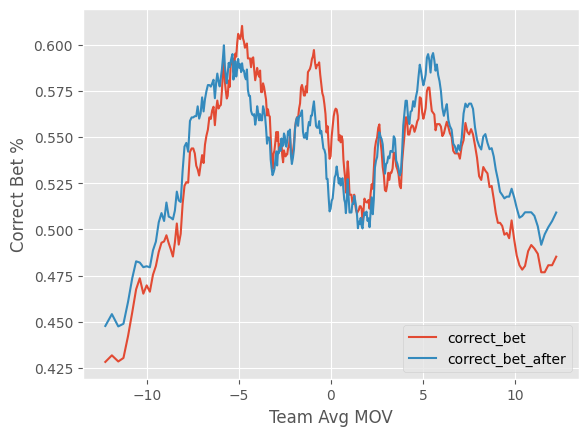

In [9]:
rolled = (
    combined.sort_values("mov")[["mov", "correct_bet", "correct_bet_after"]]
    .rolling(window=50, center=True)
    .mean()
)
rolled.plot(
    x="mov",
    y=["correct_bet", "correct_bet_after"],
    xlabel="Team Avg MOV",
    ylabel="Correct Bet %",
);

In [10]:
print(f"Overall: {df.correct_bet.mean():.03f} -> {after_df.correct_bet.mean():.03f}")

Overall: 0.530 -> 0.533


Meh. I suppose the %s did go up in the areas I was hoping for (high abs(MOV) teams)

The brier score also improved, I feel better about that sample size for that.